# Notebook 03 — Correlation Study & Hypothesis Validation

## Objectives
- Study how car attributes relate to **price** (answers Business Requirement 1).
- State the project's three hypotheses and **validate each one statistically**.

## Inputs
- `outputs/datasets/cleaned/used_cars_cleaned.csv` (97,442 cleaned rows).

## Outputs
- Correlation findings, predictive-power scores, and four plot types.
- A validated verdict for each of the three hypotheses.

> Satisfies Business Requirement 1, Pass **3.1** (data analysis & visualisation),
> Merit **1.2 / 2.3 / 4.3** (hypotheses, statistical validation, conclusions) and the
> Distinction requirement to validate at least three hypotheses.

---
## 1. Load the cleaned data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ppscore as pps
from scipy.stats import spearmanr, kruskal

sns.set_style("whitegrid")

if os.path.basename(os.getcwd()) == "jupyter_notebooks":
    os.chdir(os.path.dirname(os.getcwd()))

df = pd.read_csv("outputs/datasets/cleaned/used_cars_cleaned.csv")
print("Loaded:", df.shape)
df.head()

Loaded: (97442, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,manufacturer
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,Audi


---
## 2. Project hypotheses

We will test three hypotheses about what drives a used car's price:

1. **H1 — Mileage:** cars with **higher mileage** sell for **lower** prices.
2. **H2 — Age:** **newer** cars (more recent registration year) sell for **higher** prices.
3. **H3 — Transmission:** a car's **transmission type** is associated with its price
   (automatic and semi-automatic cars are not priced the same as manuals).

Each hypothesis is validated by statistical means below: Spearman rank correlation
(with p-values) for the numeric relationships, and a Kruskal–Wallis test for the
categorical one.

---
## 3. Correlation and predictive-power overview

First, a broad view: Spearman correlation between the numeric variables, and the
Predictive Power Score (PPS) of every feature toward `price`.

In [2]:
numeric_cols = ["year", "mileage", "engineSize", "mpg", "tax", "price"]

# Spearman correlation of each numeric feature with price
corr_with_price = (
    df[numeric_cols].corr(method="spearman")["price"]
    .drop("price").sort_values()
)
print("Spearman correlation with price:")
print(corr_with_price)

Spearman correlation with price:
mileage      -0.511066
mpg          -0.392555
tax           0.317673
engineSize    0.592151
year          0.599674
Name: price, dtype: float64


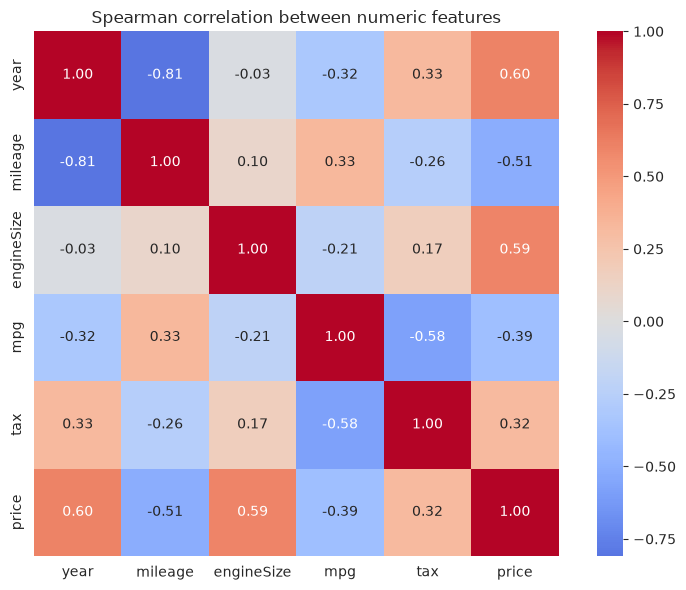

In [3]:
# Plot type 1: correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_cols].corr(method="spearman"),
    annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True
)
plt.title("Spearman correlation between numeric features")
plt.tight_layout()
plt.show()

In [4]:
# Predictive Power Score of each feature toward price (on a sample for speed)
pps_sample = df.sample(5000, random_state=0)
pps_scores = (
    pps.predictors(pps_sample, "price")[["x", "ppscore"]]
    .sort_values("ppscore", ascending=False)
    .reset_index(drop=True)
)
print("Predictive Power Score toward price:")
print(pps_scores)

Predictive Power Score toward price:
              x   ppscore
0         model  0.368680
1    engineSize  0.232808
2           mpg  0.182788
3          year  0.168417
4  transmission  0.163269
5  manufacturer  0.150197
6           tax  0.081737
7      fuelType  0.002309
8       mileage  0.000000


---
## 4. H1 — Mileage vs price

**Claim:** higher mileage → lower price (we expect a *negative* correlation).

In [5]:
coef, pval = spearmanr(df["mileage"], df["price"])
print(f"Spearman correlation (mileage vs price): {coef:.3f}  |  p-value: {pval:.3g}")

Spearman correlation (mileage vs price): -0.511  |  p-value: 0


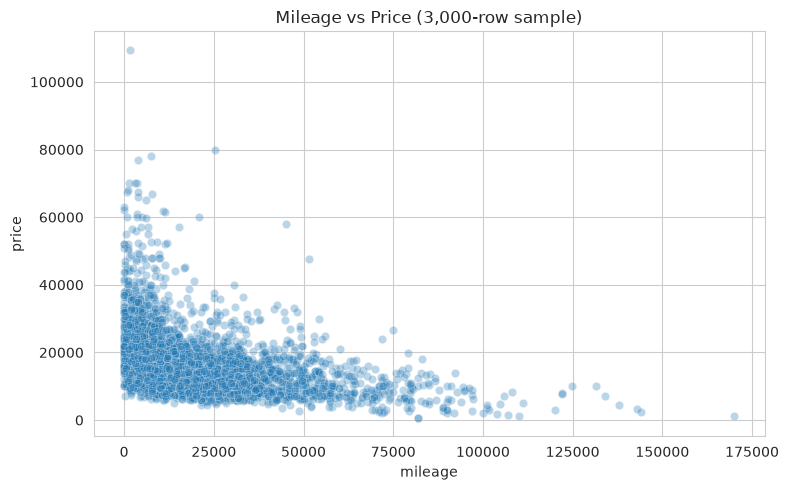

In [6]:
# Plot type 2: scatter (on a sample for readability)
sample = df.sample(3000, random_state=0)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="mileage", y="price", alpha=0.3)
plt.title("Mileage vs Price (3,000-row sample)")
plt.tight_layout()
plt.show()

---
## 5. H2 — Registration year vs price

**Claim:** newer cars → higher price (we expect a *positive* correlation).

In [7]:
coef, pval = spearmanr(df["year"], df["price"])
print(f"Spearman correlation (year vs price): {coef:.3f}  |  p-value: {pval:.3g}")

Spearman correlation (year vs price): 0.600  |  p-value: 0


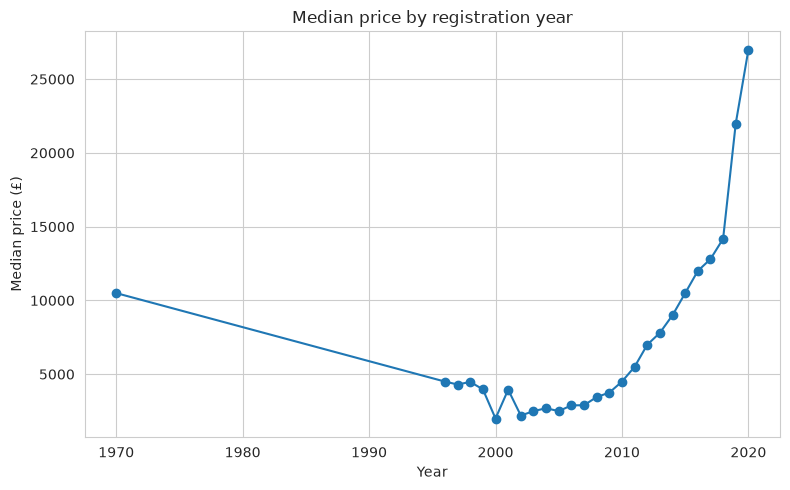

In [8]:
# Plot type 3: line of median price by year
median_by_year = df.groupby("year")["price"].median()
plt.figure(figsize=(8, 5))
median_by_year.plot(marker="o")
plt.title("Median price by registration year")
plt.ylabel("Median price (£)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

---
## 6. H3 — Transmission vs price

**Claim:** transmission type is associated with price. Because `price` is skewed, we
compare group medians and use the non-parametric **Kruskal–Wallis H-test** to check
whether the differences are statistically significant.

In [9]:
print("Median price by transmission:")
print(df.groupby("transmission")["price"].median().sort_values())

groups = [g["price"].values for _, g in df.groupby("transmission")]
H, pval = kruskal(*groups)
print(f"\nKruskal-Wallis H: {H:.1f}  |  p-value: {pval:.3g}")

Median price by transmission:
transmission
Manual       11000.0
Other        14749.0
Automatic    19230.0
Semi-Auto    22250.0
Name: price, dtype: float64

Kruskal-Wallis H: 35717.1  |  p-value: 0


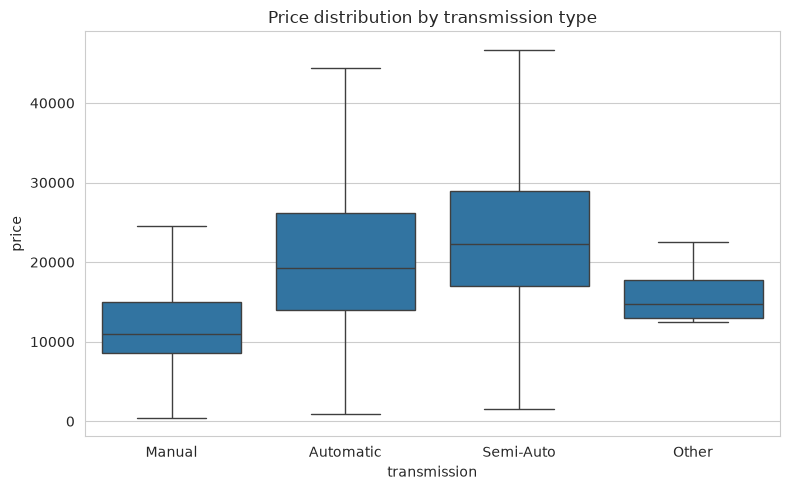

In [10]:
# Plot type 4: box plot (outliers hidden for readability)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="transmission", y="price", showfliers=False)
plt.title("Price distribution by transmission type")
plt.tight_layout()
plt.show()

## 7. Conclusions — hypothesis validation
All three hypotheses are **statistically supported**:

- **H1 — Mileage (SUPPORTED):** Spearman correlation with price = **-0.51** (p < 0.001).
  Higher mileage is strongly associated with a lower price.
- **H2 — Age (SUPPORTED):** Spearman correlation between year and price = **+0.60**
  (p < 0.001). Newer cars sell for more. Pre-2000 classics show a small upward tick
  (collector value), but the dominant modern trend is clearly positive.
- **H3 — Transmission (SUPPORTED):** median price rises from Manual (£11,000) to
  Automatic (£19,230) to Semi-Auto (£22,250); a Kruskal–Wallis test
  (H = 35,717, p < 0.001) confirms the differences are highly significant.

**Note on PPS vs correlation:** PPS ranks `model`, `engineSize` and `mpg` highest, while
`mileage` scores ~0 despite its strong correlation. PPS measures how well a *single
feature in a simple model* predicts price, so a strongly-but-non-linearly related feature
can score low alone yet still matter alongside others. Correlation with p-values is our
primary validation here.

Side-finding: `year` and `mileage` are strongly inversely correlated (-0.81) — newer
cars have lower mileage — which we will watch for multicollinearity during modelling.

Next: **Notebook 04 — Feature Engineering** (CRISP-DM: Data Preparation).